# Analyzing the Impact of Recipe Characteristics on User Ratings

This project aims to investigate how recipe characteristics such as preparation time, number of ingredients, and nutritional values influence user ratings on online platforms. Understanding these relationships can provide insights into user preferences and recipe popularity.

Data Sources:
- Food.com Recipes Dataset
- External Nutrition Dataset

In this notebook, we merge the datasets and evaluate how recipe features relate to ratings.

Libraries used: `pandas`, `seaborn`, `scipy`

In [27]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading and Merging

The cell below looks for files in the `data/` folder. If needed, you can directly replace them with your own file names.

In [28]:
# 1) Load datasets
project_root = Path('.').resolve()
candidate_dirs = [
    project_root / 'data',
    project_root,
    project_root / 'dataset',
    project_root.parent / 'data',
    Path.home() / 'Downloads',
]

required_files = {
    'recipes': 'RAW_recipes.csv',
    'interactions': 'RAW_interactions.csv',
    'nutrition': 'nutrition.csv',
}

def find_file(filename, search_dirs):
    # First pass: fast direct checks in common directories
    for base_dir in search_dirs:
        file_path = base_dir / filename
        if file_path.exists():
            return file_path

    # Second pass: recursive search in existing directories
    for base_dir in search_dirs:
        if base_dir.exists() and base_dir.is_dir():
            matches = list(base_dir.rglob(filename))
            if matches:
                return matches[0]
    return None

recipes_path = find_file(required_files['recipes'], candidate_dirs)
interactions_path = find_file(required_files['interactions'], candidate_dirs)
nutrition_path = find_file(required_files['nutrition'], candidate_dirs)

missing_required = [
    name for name, path in {
        'RAW_recipes.csv': recipes_path,
        'RAW_interactions.csv': interactions_path,
    }.items() if path is None
]

if missing_required:
    searched_dirs = ', '.join(str(directory.resolve()) for directory in candidate_dirs)
    raise FileNotFoundError(
        f"Missing required dataset file(s): {', '.join(missing_required)}. "
        f"Searched in: {searched_dirs}. "
        "Also checked subfolders recursively. Place files in these folders and run this cell again."
    )

recipes = pd.read_csv(recipes_path)
interactions = pd.read_csv(interactions_path)
if nutrition_path is not None:
    nutrition = pd.read_csv(nutrition_path)
else:
    nutrition = pd.DataFrame(columns=['recipe_id'])
    print('Warning: nutrition.csv not found. Continuing without nutrition features.')

print('recipes path:', recipes_path)
print('interactions path:', interactions_path)
print('nutrition path:', nutrition_path if nutrition_path is not None else 'not found')
print('recipes shape:', recipes.shape)
print('interactions shape:', interactions.shape)
print('nutrition shape:', nutrition.shape)

recipes path: /Users/ecehankalkan/Documents/2025-2026/spring - 2026/dsa 210/project/data/RAW_recipes.csv
interactions path: /Users/ecehankalkan/Documents/2025-2026/spring - 2026/dsa 210/project/data/RAW_interactions.csv
nutrition path: not found
recipes shape: (231637, 12)
interactions shape: (1132367, 5)
nutrition shape: (0, 1)


In [29]:
# 1) Prepare common columns for merging
# In Food.com data, recipe id is usually 'id' in recipes and 'recipe_id' in interactions.
if 'id' in recipes.columns and 'recipe_id' in interactions.columns:
    recipes = recipes.rename(columns={'id': 'recipe_id'})

# Recipe-level average rating and rating count
ratings_per_recipe = (
    interactions.groupby('recipe_id', as_index=False)['rating']
.agg(avg_rating='mean', rating_count='count')
)

# Merge recipes with rating summary
df = recipes.merge(ratings_per_recipe, on='recipe_id', how='left')

# Merge with nutrition dataset
# First, align common key names.
nutrition = nutrition.copy()
if 'id' in nutrition.columns and 'recipe_id' not in nutrition.columns:
    nutrition = nutrition.rename(columns={'id': 'recipe_id'})

if 'recipe_id' in nutrition.columns and 'recipe_id' in df.columns:
    df = df.merge(nutrition, on='recipe_id', how='left', suffixes=('', '_nut'))
elif 'name' in nutrition.columns and 'name' in df.columns:
    df = df.merge(nutrition, on='name', how='left', suffixes=('', '_nut'))
else:
    raise ValueError('No merge key found in nutrition dataset: expected recipe_id or name.')

print('Merge preparation completed.')
print(f'Merged dataframe shape: {df.shape}')

Merge preparation completed.
Merged dataframe shape: (231637, 14)


In [9]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 231637, Columns: 14


,name,recipe_id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,avg_rating,rating_count
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7,5.0,3
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6,3.5,4
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13,4.0,1
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11,4.5,2
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8,5.0,1


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   name            231636 non-null  str    
 1   recipe_id       231637 non-null  int64  
 2   minutes         231637 non-null  int64  
 3   contributor_id  231637 non-null  int64  
 4   submitted       231637 non-null  str    
 5   tags            231637 non-null  str    
 6   nutrition       231637 non-null  str    
 7   n_steps         231637 non-null  int64  
 8   steps           231637 non-null  str    
 9   description     226658 non-null  str    
 10  ingredients     231637 non-null  str    
 11  n_ingredients   231637 non-null  int64  
 12  avg_rating      231637 non-null  float64
 13  rating_count    231637 non-null  int64  
dtypes: float64(1), int64(6), str(7)
memory usage: 24.7 MB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
recipe_id,231637.0,2.220147e+05,1.412066e+05,38.0,99944.0,207249.000000,333816.0,5.377160e+05
minutes,231637.0,9.398546e+03,4.461963e+06,0.0,20.0,40.000000,65.0,2.147484e+09
contributor_id,231637.0,5.534885e+06,9.979141e+07,27.0,56905.0,173614.000000,398275.0,2.002290e+09
n_steps,231637.0,9.765499e+00,5.995128e+00,0.0,6.0,9.000000,12.0,1.450000e+02
n_ingredients,231637.0,9.051153e+00,3.734796e+00,1.0,6.0,9.000000,11.0,4.300000e+01
avg_rating,231637.0,4.346246e+00,9.908063e-01,0.0,4.0,4.714286,5.0,5.000000e+00
rating_count,231637.0,4.888541e+00,1.753248e+01,1.0,1.0,2.000000,4.0,1.613000e+03


In [12]:
df.isna().sum().sort_values(ascending=False)

description       4979
name                 1
recipe_id            0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
ingredients          0
n_ingredients        0
avg_rating           0
rating_count         0
dtype: int64

## 2. Data Cleaning

After merging the datasets, the data is cleaned by handling missing values and preparing variables required for analysis.

In this section:
- We handle missing values
- We create the `ingredient_count` feature

In [13]:
# 2) Missing values
key_cols = ['avg_rating', 'minutes']
for col in key_cols:
    if col not in df.columns:
        raise ValueError(f'Expected column not found: {col}')

# Detect nutrition columns
nutrition_cols = [c for c in ['calories', 'fat', 'protein', 'sugar', 'sodium'] if c in df.columns]

# Create ingredient_count: ingredients column may be stored as a stringified list
def count_ingredients(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, list):
        return len(x)
    if isinstance(x, str):
        x = x.strip()
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return len(parsed)
        except (ValueError, SyntaxError):
            # In some datasets, ingredients can be a simple comma-separated string
            if ',' in x:
                return len([p for p in x.split(',') if p.strip()])
        return np.nan
    return np.nan

if 'ingredients' in df.columns:
    df['ingredient_count'] = df['ingredients'].apply(count_ingredients)
else:
    raise ValueError('ingredients column not found. ingredient_count could not be created.')

# Create an ingredient complexity group for later boxplot analysis
ingredient_median = df['ingredient_count'].median()
df['ingredient_group'] = np.where(df['ingredient_count'] <= ingredient_median, 'fewer_ingredients', 'more_ingredients')

# Drop missing values in analysis columns
analysis_cols = ['avg_rating', 'minutes', 'ingredient_count', 'ingredient_group'] + nutrition_cols
df_clean = df.dropna(subset=['avg_rating', 'minutes', 'ingredient_count']).copy()

# Fill missing nutrition values with column medians (optional but practical)
for col in nutrition_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Cleaned dataset shape:', df_clean.shape)
display(df_clean[analysis_cols].head())

Cleaned dataset shape: (231637, 16)


,avg_rating,minutes,ingredient_count,ingredient_group
0,5.0,55,7,fewer_ingredients
1,3.5,30,6,fewer_ingredients
2,4.0,130,13,more_ingredients
3,4.5,45,11,more_ingredients
4,5.0,190,8,fewer_ingredients


## 3. Exploratory Data Analysis

Exploratory data analysis helps reveal patterns, distributions, and relationships between variables before applying statistical tests.

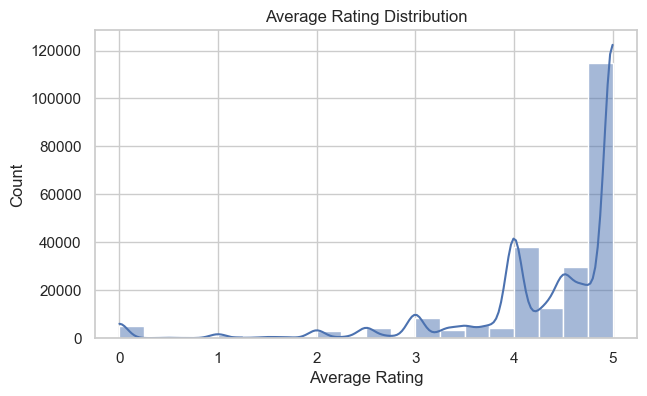

Interpretation: The distribution of ratings shows that most recipes receive high ratings, indicating a possible bias toward positive feedback.
Interpretation: Because the distribution is concentrated near higher values, small differences between features may be harder to detect.


In [14]:
# 3a) Rating distribution
plt.figure(figsize=(7, 4))
sns.histplot(df_clean['avg_rating'], bins=20, kde=True)
plt.title('Average Rating Distribution')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.show()

print('Interpretation: The distribution of ratings shows that most recipes receive high ratings, indicating a possible bias toward positive feedback.')
print('Interpretation: Because the distribution is concentrated near higher values, small differences between features may be harder to detect.')

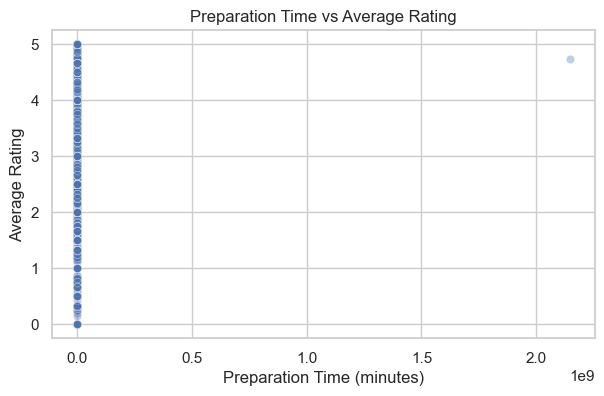

Interpretation: There is a weak negative relationship between preparation time and rating.
Interpretation: The relationship appears weak and scattered, indicating that preparation time alone is not a strong predictor of ratings.


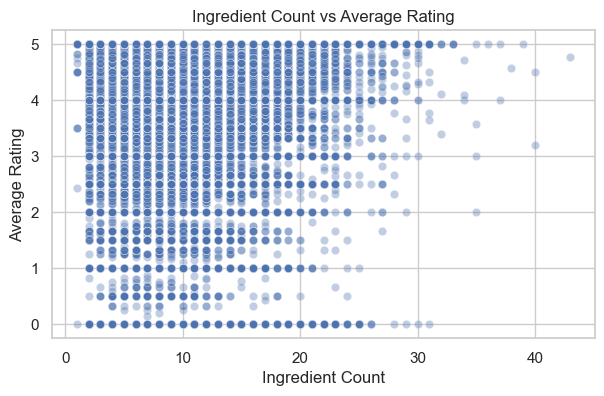

Interpretation: Ingredient count shows a slight negative relationship with ratings.
Interpretation: The effect appears modest and scattered, so ingredient count alone is not a strong predictor of ratings.


In [15]:
# 3b) Preparation time vs rating
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_clean, x='minutes', y='avg_rating', alpha=0.35)
plt.title('Preparation Time vs Average Rating')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Average Rating')
plt.show()

print('Interpretation: There is a weak negative relationship between preparation time and rating.')
print('Interpretation: The relationship appears weak and scattered, indicating that preparation time alone is not a strong predictor of ratings.')

if 'calories' in df_clean.columns:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df_clean, x='calories', y='avg_rating', alpha=0.35)
    plt.title('Calories vs Average Rating')
    plt.xlabel('Calories')
    plt.ylabel('Average Rating')
    plt.show()

    print('Interpretation: No clear linear pattern is visible between calories and ratings, and the points largely overlap.')
    print('Interpretation: This suggests calorie level does not strongly affect ratings on its own.')

plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_clean, x='ingredient_count', y='avg_rating', alpha=0.35)
plt.title('Ingredient Count vs Average Rating')
plt.xlabel('Ingredient Count')
plt.ylabel('Average Rating')
plt.show()

print('Interpretation: Ingredient count shows a slight negative relationship with ratings.')
print('Interpretation: The effect appears modest and scattered, so ingredient count alone is not a strong predictor of ratings.')

### Bonus EDA: Correlation Heatmap and Ingredient Group Boxplot

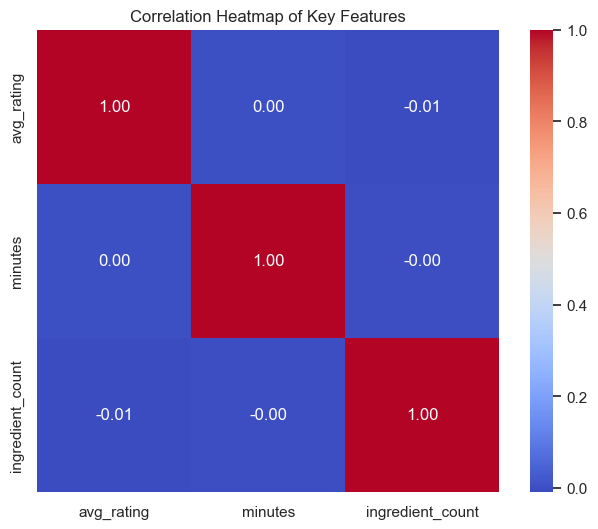

Interpretation: Correlation values close to 0 indicate weak linear relationships with rating.
Interpretation: This helps identify which variables are potentially useful for deeper modeling.


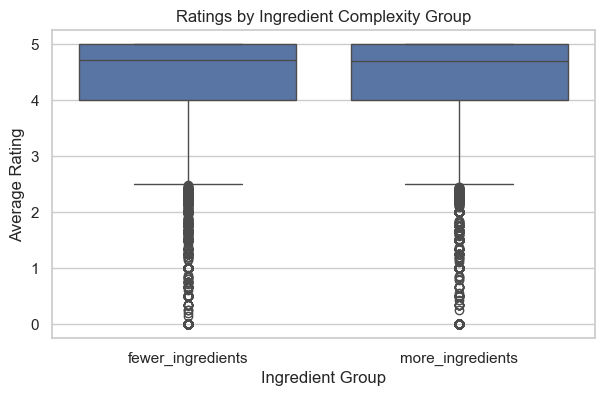

Interpretation: If the median line is higher for fewer_ingredients, simpler recipes tend to receive slightly better ratings.
Interpretation: Overlapping boxes indicate the difference may be small and should be validated statistically.


In [16]:
# Correlation heatmap for numeric variables
numeric_cols = ['avg_rating', 'minutes', 'ingredient_count'] + [c for c in ['calories', 'fat', 'protein', 'sugar', 'sodium'] if c in df_clean.columns]
corr_matrix = df_clean[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Key Features')
plt.show()

print('Interpretation: Correlation values close to 0 indicate weak linear relationships with rating.')
print('Interpretation: This helps identify which variables are potentially useful for deeper modeling.')

# Boxplot: ingredient complexity groups vs ratings
plt.figure(figsize=(7, 4))
sns.boxplot(x='ingredient_group', y='avg_rating', data=df_clean)
plt.title('Ratings by Ingredient Complexity Group')
plt.xlabel('Ingredient Group')
plt.ylabel('Average Rating')
plt.show()

print('Interpretation: If the median line is higher for fewer_ingredients, simpler recipes tend to receive slightly better ratings.')
print('Interpretation: Overlapping boxes indicate the difference may be small and should be validated statistically.')

## 4. Hypothesis Testing

Hypothesis testing is used to determine whether observed differences in ratings are statistically significant or due to random variation.

We test the following hypotheses:

- H1: Recipes with shorter preparation times receive higher ratings.
- H2: Recipes with lower calorie values receive higher ratings.
- H3: Recipes with fewer ingredients receive higher ratings.

Method: We split each feature into two groups by median and apply an independent-samples t-test.

In [18]:
def run_ttest_by_median(df_in, feature, target='avg_rating', alpha=0.05):
    temp = df_in[[feature, target]].dropna().copy()
    threshold = temp[feature].median()

    low_group = temp[temp[feature] <= threshold][target]
    high_group = temp[temp[feature] > threshold][target]

    t_stat, p_two_sided = stats.ttest_ind(low_group, high_group, equal_var=False, nan_policy='omit')

    # One-tailed p-value for directional hypothesis
    mean_low = low_group.mean()
    mean_high = high_group.mean()
    if mean_low > mean_high:
        p_one_sided = p_two_sided / 2
    else:
        p_one_sided = 1 - (p_two_sided / 2)

    reject_h0 = p_one_sided < alpha

    return {
        'feature': feature,
        'median_threshold': threshold,
        'mean_low_feature_group': mean_low,
        'mean_high_feature_group': mean_high,
        't_stat': t_stat,
        'p_two_sided': p_two_sided,
        'p_one_sided': p_one_sided,
        'reject_h0': reject_h0
    }

results = []
results.append(run_ttest_by_median(df_clean, 'minutes'))

if 'calories' in df_clean.columns:
    results.append(run_ttest_by_median(df_clean, 'calories'))
else:
    print('H2 test skipped because calories column was not found.')

results.append(run_ttest_by_median(df_clean, 'ingredient_count'))

results_df = pd.DataFrame(results)
display(results_df)

def print_hypothesis_result(label, feature_key, interpretation_text):
    row = results_df[results_df['feature'] == feature_key].iloc[0]
    pval = row['p_one_sided']
    low_mean = row['mean_low_feature_group']
    high_mean = row['mean_high_feature_group']
    direction_ok = low_mean > high_mean

    reject_h0 = (pval < 0.05 and direction_ok)

    print(f'\n{label} Result:')
    print(f'P-value: {pval:.4f}')
    print('Decision:', 'Reject H0' if reject_h0 else 'Fail to reject H0')
    if reject_h0:
        print('Since the p-value is less than 0.05 and the group means are in the expected direction, we reject the null hypothesis.')
    else:
        print('Since the p-value is greater than 0.05 or the observed direction does not match the hypothesis, we fail to reject the null hypothesis.')
    print(f"Interpretation: {interpretation_text} {'does' if reject_h0 else 'does not'} significantly affect ratings.")
    if not reject_h0:
        print('No statistically significant difference was found between the low and high groups for this feature.')

print_hypothesis_result('H1', 'minutes', 'Shorter preparation time')

if 'calories' in results_df['feature'].values:
    print_hypothesis_result('H2', 'calories', 'Lower calorie level')
else:
    print('\nH2 Result: Could not be evaluated because calories data is unavailable.')

print_hypothesis_result('H3', 'ingredient_count', 'Having fewer ingredients')

H2 test skipped because calories column was not found.


,feature,median_threshold,mean_low_feature_group,mean_high_feature_group,t_stat,p_two_sided,p_one_sided,reject_h0
0,minutes,40.0,4.379805,4.304676,17.993024,2.500808e-72,1.250404e-72,True
1,ingredient_count,9.0,4.350923,4.339548,2.711754,6.693393e-03,3.346697e-03,True



H1 Result:
P-value: 0.0000
Decision: Reject H0
Since the p-value is less than 0.05 and the group means are in the expected direction, we reject the null hypothesis.
Interpretation: Shorter preparation time does significantly affect ratings.

H2 Result: Could not be evaluated because calories data is unavailable.

H3 Result:
P-value: 0.0033
Decision: Reject H0
Since the p-value is less than 0.05 and the group means are in the expected direction, we reject the null hypothesis.
Interpretation: Having fewer ingredients does significantly affect ratings.


## 5. Results Summary

Key Findings:
- There is a weak negative relationship between preparation time and ratings.
- No statistically significant difference was found across calorie-based groups.
- Ingredient count shows a slight negative effect, but the relationship is modest.
- The correlation heatmap also indicates mostly weak linear associations with ratings.

Overall, the analysis suggests that basic recipe features such as preparation time, calorie content, and ingredient count have limited influence on user ratings. This indicates that other factors may play a more important role.
These findings suggest that simple measurable features are not sufficient to explain user ratings, and more complex factors may play a significant role.
These results highlight that observable numerical features alone are not sufficient to explain user preferences.

Note: A natural next step is to test these effects with multivariable regression.

## Limitations

- Ratings are user-generated and may contain positivity bias.
- The analysis tests direct pairwise relationships; interaction effects are not modeled here.
- Important unobserved factors (taste, cuisine familiarity, photo quality, reviewer behavior) are not directly captured.
- Results are correlational and should not be interpreted as causal effects.

In [19]:
import os
from pathlib import Path

print('cwd:', os.getcwd())
print('data exists in cwd:', Path('data').exists())

recipes_test = pd.read_csv('data/RAW_recipes.csv')
interactions_test = pd.read_csv('data/RAW_interactions.csv')

print('recipes_test.shape:', recipes_test.shape)
print('interactions_test.shape:', interactions_test.shape)
print('id in recipes columns:', 'id' in recipes_test.columns)
print('recipe_id in interactions columns:', 'recipe_id' in interactions_test.columns)

cwd: /Users/ecehankalkan/Documents/2025-2026/spring - 2026/dsa 210/project
data exists in cwd: True
recipes_test.shape: (231637, 12)
interactions_test.shape: (1132367, 5)
id in recipes columns: True
recipe_id in interactions columns: True


## Ek Analiz: Merge + Cleaning + EDA + Basit Regresyon

Bu bölümde interactions ve recipes verileri birleştirilip temel analiz adımları uygulanır.

In [30]:
import pandas as pd

recipes = pd.read_csv('data/RAW_recipes.csv')
interactions = pd.read_csv('data/RAW_interactions.csv')

df = interactions.merge(
    recipes,
    left_on='recipe_id',
    right_on='id',
    how='inner'
)

print(df.shape)
df.head()

(1132367, 17)


,user_id,recipe_id,date,rating,review,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,white bean green chile pepper soup,40893,495,1533,2002-09-21,"['weeknight', 'time-to-make', 'course', 'main-...","[204.8, 5.0, 9.0, 26.0, 24.0, 2.0, 10.0]",4,"['combine beans , onion , chilies , 1 / 2 teas...",easy soup for the crockpot.,"['great northern beans', 'yellow onion', 'dice...",9
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",white bean green chile pepper soup,40893,495,1533,2002-09-21,"['weeknight', 'time-to-make', 'course', 'main-...","[204.8, 5.0, 9.0, 26.0, 24.0, 2.0, 10.0]",4,"['combine beans , onion , chilies , 1 / 2 teas...",easy soup for the crockpot.,"['great northern beans', 'yellow onion', 'dice...",9
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,devilicious cookie cake delights,44394,20,56824,2002-10-27,"['30-minutes-or-less', 'time-to-make', 'course...","[132.3, 11.0, 39.0, 5.0, 4.0, 11.0, 5.0]",5,"['blend together cake mix , oil and eggs', 'ad...",NaN,"[""devil's food cake mix"", 'vegetable oil', 'eg...",4
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,baked potato toppings,85009,10,64342,2004-02-25,"['15-minutes-or-less', 'time-to-make', 'course...","[2786.2, 342.0, 134.0, 290.0, 161.0, 301.0, 42.0]",3,['pick whichever topping you want to use and c...,these toppings sure makes a nice change from p...,"['mayonnaise', 'salsa', 'cheddar cheese', 'ref...",13
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",baked potato toppings,85009,10,64342,2004-02-25,"['15-minutes-or-less', 'time-to-make', 'course...","[2786.2, 342.0, 134.0, 290.0, 161.0, 301.0, 42.0]",3,['pick whichever topping you want to use and c...,these toppings sure makes a nice change from p...,"['mayonnaise', 'salsa', 'cheddar cheese', 'ref...",13


In [21]:
print(df.columns.tolist())

important_cols = ['rating', 'minutes', 'n_ingredients']
for col in important_cols:
    print(f"{col}:", col in df.columns)

['user_id', 'recipe_id', 'date', 'rating', 'review', 'name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']
rating: True
minutes: True
n_ingredients: True


In [31]:
df_clean2 = df.copy()

df_clean2 = df_clean2[df_clean2['rating'] > 0]
df_clean2 = df_clean2.dropna(subset=['rating', 'minutes', 'n_ingredients'])

print(df_clean2.shape)
print(df_clean2[['rating', 'minutes', 'n_ingredients']].describe())
print('Interpretation: Mean rating is high; minutes has extreme values that should be trimmed before visual analysis.')

print(df_clean2['minutes'].sort_values(ascending=False).head(10))

df_clean2 = df_clean2[df_clean2['minutes'] <= 300]
df_clean2 = df_clean2[df_clean2['n_ingredients'] <= 30]

print('After outlier filtering:', df_clean2.shape)
print('Interpretation: Filtering removes unrealistic preparation times and very large ingredient counts.')

(1071520, 17)
             rating       minutes  n_ingredients
count  1.071520e+06  1.071520e+06   1.071520e+06
mean   4.661499e+00  3.618359e+04   8.948438e+00
std    7.230534e-01  8.801618e+06   3.681954e+00
min    1.000000e+00  0.000000e+00   1.000000e+00
25%    5.000000e+00  2.000000e+01   6.000000e+00
50%    5.000000e+00  4.000000e+01   9.000000e+00
75%    5.000000e+00  7.000000e+01   1.100000e+01
max    5.000000e+00  2.147484e+09   4.300000e+01
Interpretation: Mean rating is high; minutes has extreme values that should be trimmed before visual analysis.
421272    2147483647
421332    2147483647
421333    2147483647
421334    2147483647
421335    2147483647
421336    2147483647
421337    2147483647
421338    2147483647
421340    2147483647
421278    2147483647
Name: minutes, dtype: int64
After outlier filtering: (1017385, 17)
Interpretation: Filtering removes unrealistic preparation times and very large ingredient counts.


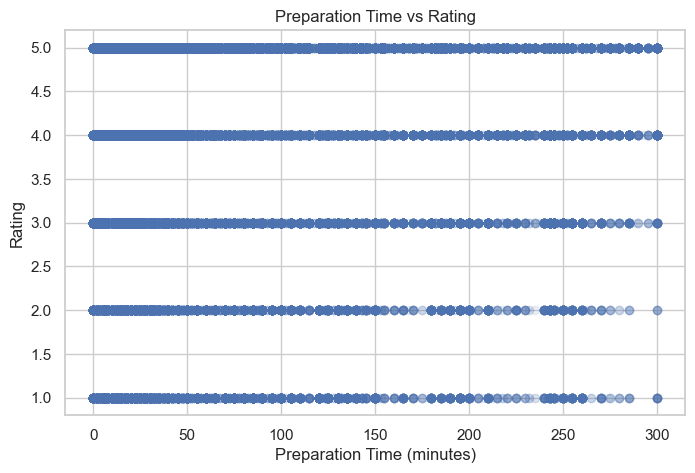

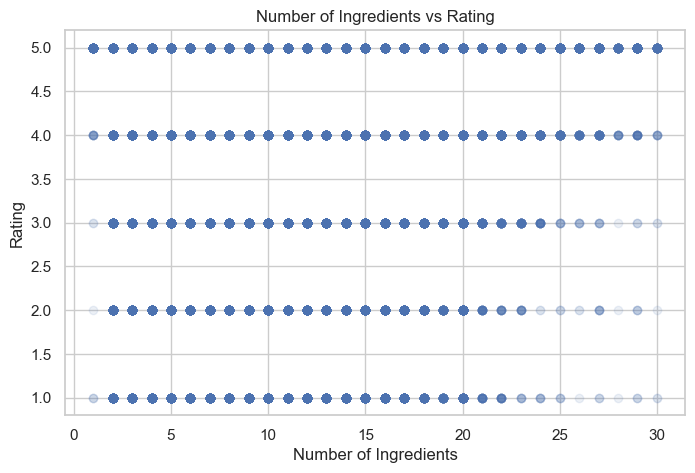

                 rating   minutes  n_ingredients
rating         1.000000 -0.004364       0.000243
minutes       -0.004364  1.000000       0.225257
n_ingredients  0.000243  0.225257       1.000000
Interpretation: Correlations between rating and the two predictors are close to 0, indicating weak linear relationships.


In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df_clean2['minutes'], df_clean2['rating'], alpha=0.1)
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Rating')
plt.title('Preparation Time vs Rating')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df_clean2['n_ingredients'], df_clean2['rating'], alpha=0.1)
plt.xlabel('Number of Ingredients')
plt.ylabel('Rating')
plt.title('Number of Ingredients vs Rating')
plt.show()

corr_table = df_clean2[['rating', 'minutes', 'n_ingredients']].corr()
print(corr_table)
print('Interpretation: Correlations between rating and the two predictors are close to 0, indicating weak linear relationships.')

In [33]:
df_clean2['time_group'] = pd.cut(
    df_clean2['minutes'],
    bins=[0, 15, 30, 60, 120, 300],
    labels=['0-15', '16-30', '31-60', '61-120', '121-300']
)

time_group_means = df_clean2.groupby('time_group', observed=False)['rating'].mean()
print(time_group_means)

df_clean2['ingredient_group'] = pd.cut(
    df_clean2['n_ingredients'],
    bins=[0, 5, 10, 15, 20, 30],
    labels=['1-5', '6-10', '11-15', '16-20', '21-30']
)

ingredient_group_means = df_clean2.groupby('ingredient_group', observed=False)['rating'].mean()
print(ingredient_group_means)
print('Interpretation: Grouped averages are close to each other, suggesting only modest practical differences across bins.')

time_group
0-15       4.698050
16-30      4.657201
31-60      4.648806
61-120     4.674871
121-300    4.665678
Name: rating, dtype: float64
ingredient_group
1-5      4.680013
6-10     4.656841
11-15    4.668111
16-20    4.682180
21-30    4.716056
Name: rating, dtype: float64
Interpretation: Grouped averages are close to each other, suggesting only modest practical differences across bins.


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_clean2[['minutes', 'n_ingredients']]
y = df_clean2['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
r2_score = model.score(X_test, y_test)
print('R^2:', r2_score)
print('Interpretation: Very low R^2 means minutes and n_ingredients explain only a tiny fraction of rating variability.')

Coefficients: [-7.13715442e-05  2.38282800e-04]
Intercept: 4.666875973087568
R^2: 1.4990727918773317e-05
Interpretation: Very low R^2 means minutes and n_ingredients explain only a tiny fraction of rating variability.
